In [1]:
import zipfile
zip = zipfile.ZipFile(r"/content/drive/MyDrive/archive.zip",'r')
zip.extractall("/content")
zip.close()

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanIoU
from sklearn.model_selection import train_test_split

# DATASET LOADER

In [4]:
import glob
from PIL import Image
import numpy as np

image_paths = sorted(glob.glob('images/*.png'))
mask_paths  = sorted(glob.glob('masks/*_mask.png'))

# Load — masks are already binary (0 or 255), just normalize
X = np.array([np.array(Image.open(p).resize((256,256))) for p in image_paths]) / 255.0
y = np.array([np.array(Image.open(p).resize((256,256))) for p in mask_paths])  / 255.0

# y values are now exactly 0.0 (background) or 1.0 (gland) — ready for BCE or Dice loss
y = y[..., np.newaxis]  # add channel dim → shape (N, 256, 256, 1)

In [5]:
def load_warwick_dataset(base_path):
    images = []
    masks = []

    files = sorted(os.listdir(base_path))

    for file in files:
        if file.endswith(".bmp") and "_anno" not in file:

            img_path = os.path.join(base_path, file)
            mask_path = os.path.join(
                base_path,
                file.replace(".bmp", "_anno.bmp")
            )

            if not os.path.exists(mask_path):
                continue

            # Load image
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img.astype(np.float32) / 255.0

            # Load mask
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
            mask = (mask > 0).astype(np.float32)
            mask = np.expand_dims(mask, axis=-1)

            images.append(img)
            masks.append(mask)

    return np.array(images), np.array(masks)

In [8]:
df=pd.read_csv("/content/Warwick_QU_Dataset/GLAS.csv")
df.columns = [col.strip() for col in df.columns] # Robustly strip whitespace from all column names
df.rename(columns={'grade (GlaS)': 'grade_GlaS', 'grade (Sirinukunwattana et al. 2015)': 'grade_Sirinukunwattana'}, inplace=True)
print(df.columns.tolist())
df.sample(10)

['name', 'patient ID', 'grade_GlaS', 'grade_Sirinukunwattana']


,name,patient ID,grade_GlaS,grade_Sirinukunwattana
40,testA_46,4,benign,adenomatous
144,train_68,1,malignant,poorly differentiated
42,testA_48,4,malignant,poorly differentiated
109,train_36,16,malignant,moderately differentiated
99,train_27,1,malignant,moderately-to-poorly differentated
135,train_6,3,benign,adenomatous
75,testB_5,5,benign,adenomatous
90,train_19,3,malignant,moderately differentiated
57,testA_7,4,benign,adenomatous
138,train_62,9,benign,healthy


In [9]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   name                    165 non-null    object
 1   patient ID              165 non-null    int64 
 2   grade_GlaS              165 non-null    object
 3   grade_Sirinukunwattana  165 non-null    object
dtypes: int64(1), object(3)
memory usage: 5.3+ KB
None
       patient ID
count  165.000000
mean     6.490909
std      3.906870
min      1.000000
25%      3.000000
50%      7.000000
75%     10.000000
max     16.000000


In [10]:
df.shape

(165, 4)

In [11]:
df['grade_Sirinukunwattana'].unique()

array([' adenomatous', ' healthy', ' poorly differentiated',
       ' moderately differentiated',
       ' moderately-to-poorly differentated'], dtype=object)

In [12]:
df['grade_Sirinukunwattana'].value_counts()

,count
grade_Sirinukunwattana,
moderately differentiated,47
healthy,42
adenomatous,32
poorly differentiated,24
moderately-to-poorly differentated,20


### Statistical Visualizations of `df` DataFrame

Let's visualize the distribution of grades in the `df` DataFrame to understand the class balance and the relationship between the two grading systems.

In [13]:
df['grade_GlaS'].value_counts()

,count
grade_GlaS,
malignant,91
benign,74


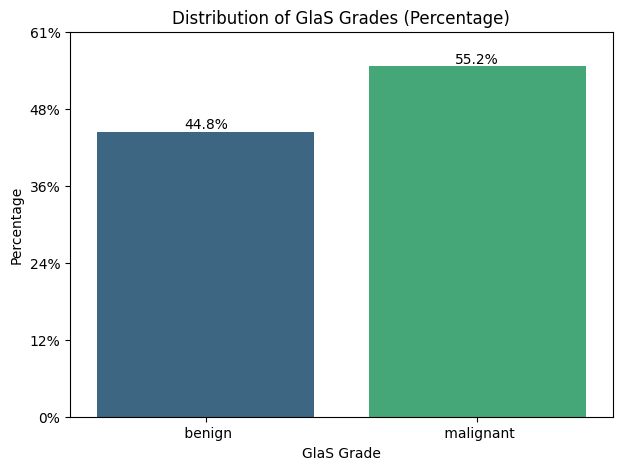

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Visualization 1: Distribution of 'grade (GlaS)'
plt.figure(figsize=(7, 5))

# Create countplot
ax = sns.countplot(x='grade_GlaS', data=df, palette='viridis', hue='grade_GlaS', legend=False)

# Convert y-axis to percentage using PercentFormatter
total = len(df['grade_GlaS'])
yticks = ax.get_yticks()
ax.set_yticks(yticks) # Set fixed y-tick locations
formatter = mticker.PercentFormatter(xmax=total, decimals=0) # xmax is the total count for 100%
ax.yaxis.set_major_formatter(formatter)

# Labels and title
plt.title('Distribution of GlaS Grades (Percentage)')
plt.xlabel('GlaS Grade')
plt.ylabel('Percentage')

# Add percentage labels on bars
for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()

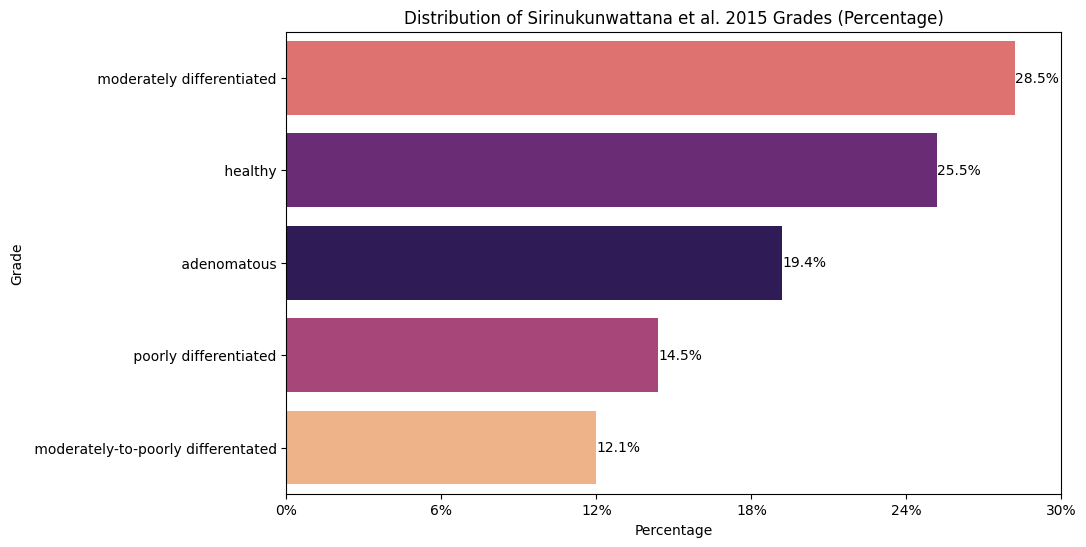

In [15]:
import matplotlib.ticker as mticker

# Visualization 2: Distribution of 'grade (Sirinukunwattana et al. 2015)'

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    y='grade_Sirinukunwattana',
    data=df,
    palette='magma',
    order=df['grade_Sirinukunwattana'].value_counts().index,
    hue='grade_Sirinukunwattana',
    legend=False
)

# Convert x-axis to percentage using PercentFormatter
total = len(df['grade_Sirinukunwattana'])
xticks = ax.get_xticks()
ax.set_xticks(xticks) # Set fixed x-tick locations to avoid UserWarning
formatter = mticker.PercentFormatter(xmax=total, decimals=0) # xmax is the total count for 100%
ax.xaxis.set_major_formatter(formatter)

# Titles and labels
plt.title('Distribution of Sirinukunwattana et al. 2015 Grades (Percentage)')
plt.xlabel('Percentage')
plt.ylabel('Grade')

# Add percentage labels on bars
for p in ax.patches:
    percentage = 100 * p.get_width() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center')

plt.show()

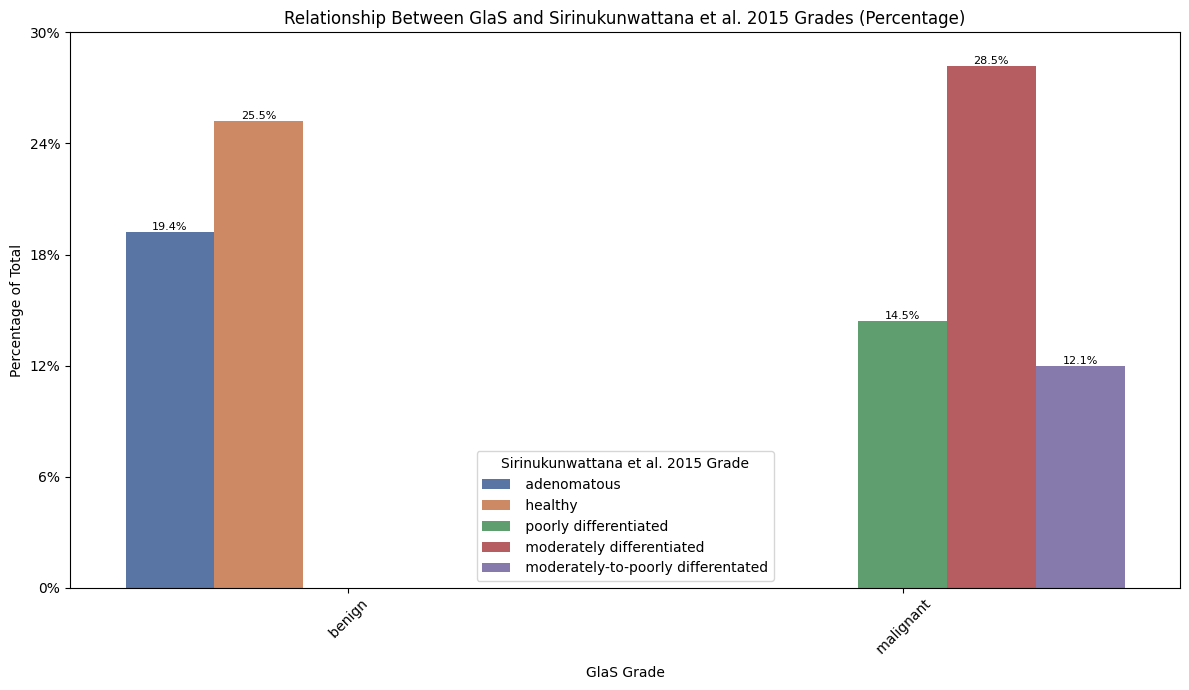

In [16]:
# Visualization 3: Relationship between the two grading systems
plt.figure(figsize=(12, 7))
ax = sns.countplot(x='grade_GlaS', hue='grade_Sirinukunwattana', data=df, palette='deep')
plt.title('Relationship Between GlaS and Sirinukunwattana et al. 2015 Grades (Percentage)')
plt.xlabel('GlaS Grade')

# Calculate total count for overall percentage
total_overall = len(df)

# Apply PercentageFormatter to the y-axis
yticks = ax.get_yticks()
ax.set_yticks(yticks)
formatter = mticker.PercentFormatter(xmax=total_overall, decimals=0)
ax.yaxis.set_major_formatter(formatter)
plt.ylabel('Percentage of Total') # Update y-axis label

plt.xticks(rotation=45)
plt.legend(title='Sirinukunwattana et al. 2015 Grade')

# Add percentages to bars (now relative to overall total)
for container in ax.containers:
    for patch in container.patches:
        height = patch.get_height()
        if height == 0:
            continue

        # Calculate percentage relative to the overall total
        percentage = '{:.1f}%'.format(100 * height / total_overall)
        ax.annotate(percentage,
                    (patch.get_x() + patch.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=8, color='black')

plt.tight_layout()
plt.show()

# LOAD DATASET

In [17]:
GLAS_PATH="/content/Warwick_QU_Dataset"
IMG_SIZE = 256 # Define IMG_SIZE here
X, y = load_warwick_dataset(GLAS_PATH)

print("Total Images:", X.shape)
print("Total Masks :", y.shape)

Total Images: (165, 256, 256, 3)
Total Masks : (165, 256, 256, 1)


In [18]:
X

array([[[[0.98039216, 0.91764706, 0.9607843 ],
         [0.8117647 , 0.68235296, 0.8862745 ],
         [0.9137255 , 0.827451  , 0.9019608 ],
         ...,
         [0.9607843 , 0.9372549 , 0.9254902 ],
         [0.95686275, 0.8980392 , 0.9098039 ],
         [0.8235294 , 0.69411767, 0.92941177]],

        [[0.98039216, 0.94509804, 0.9372549 ],
         [0.9372549 , 0.8666667 , 0.9411765 ],
         [0.9764706 , 0.92156863, 0.94509804],
         ...,
         [0.9882353 , 0.9647059 , 0.9607843 ],
         [0.972549  , 0.92156863, 0.92941177],
         [0.85490197, 0.7411765 , 0.9254902 ]],

        [[0.95686275, 0.9254902 , 0.9490196 ],
         [0.972549  , 0.92941177, 0.96862745],
         [0.9882353 , 0.94509804, 0.9764706 ],
         ...,
         [0.9647059 , 0.9411765 , 0.94509804],
         [0.9882353 , 0.94509804, 0.9372549 ],
         [0.89411765, 0.8       , 0.92156863]],

        ...,

        [[0.6509804 , 0.46666667, 0.7058824 ],
         [0.6039216 , 0.4117647 , 0.7019608 ]

In [19]:
y

array([[[[1.],
         [1.],
         [1.],
         ...,
         [1.],
         [1.],
         [1.]],

        [[1.],
         [1.],
         [1.],
         ...,
         [1.],
         [1.],
         [1.]],

        [[1.],
         [1.],
         [1.],
         ...,
         [1.],
         [1.],
         [1.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [1.],
         [1.],
         [1.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [1.],
         [1.],
         [1.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [1.],
         [1.],
         [1.]]],


       [[[1.],
         [1.],
         [1.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[1.],
         [1.],
         [1.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[1.],
         [1.],
         [1.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

# SPLIT DATA


In [20]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Train: (115, 256, 256, 3)
Val  : (25, 256, 256, 3)
Test : (25, 256, 256, 3)


In [21]:
y_test

array([[[[0.],
         [1.],
         [1.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [1.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[1.],
         [1.],
         [1.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[1.],
         [1.],
         [1.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[1.],
         [1.],
         [1.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [1.],
         [1.],
         [1.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [1.],
         [1.],
         [1.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [1.],
         [1.],
         [1.]],

        ...,

        [[0.],
 

In [22]:
X_train

array([[[[0.7490196 , 0.5176471 , 0.7607843 ],
         [0.7372549 , 0.52156866, 0.8156863 ],
         [0.7137255 , 0.5058824 , 0.8039216 ],
         ...,
         [0.7882353 , 0.5294118 , 0.84705883],
         [0.91764706, 0.6862745 , 0.9254902 ],
         [0.88235295, 0.6509804 , 0.87058824]],

        [[0.5254902 , 0.28235295, 0.6627451 ],
         [0.57254905, 0.3529412 , 0.7058824 ],
         [0.77254903, 0.5647059 , 0.83137256],
         ...,
         [0.8235294 , 0.58431375, 0.8352941 ],
         [0.88235295, 0.67058825, 0.89411765],
         [0.9098039 , 0.70980394, 0.9137255 ]],

        [[0.49019608, 0.23529412, 0.6627451 ],
         [0.6431373 , 0.4       , 0.7294118 ],
         [0.8901961 , 0.6745098 , 0.8666667 ],
         ...,
         [0.9254902 , 0.7372549 , 0.9019608 ],
         [0.87058824, 0.6745098 , 0.8980392 ],
         [0.92941177, 0.7490196 , 0.9490196 ]],

        ...,

        [[0.98039216, 0.8784314 , 0.94509804],
         [0.90588236, 0.7764706 , 0.9137255 ]

In [23]:
X_temp

array([[[[0.9411765 , 0.5647059 , 0.827451  ],
         [0.8627451 , 0.5176471 , 0.83137256],
         [0.89411765, 0.54901963, 0.8235294 ],
         ...,
         [0.6627451 , 0.42745098, 0.5411765 ],
         [0.972549  , 0.77254903, 0.8862745 ],
         [0.8980392 , 0.7019608 , 0.87058824]],

        [[0.91764706, 0.5254902 , 0.8       ],
         [0.84705883, 0.48235294, 0.8352941 ],
         [0.7411765 , 0.42352942, 0.8235294 ],
         ...,
         [0.9019608 , 0.7137255 , 0.85490197],
         [0.972549  , 0.7764706 , 0.9019608 ],
         [0.85882354, 0.6627451 , 0.85490197]],

        [[0.9529412 , 0.62352943, 0.84313726],
         [0.6431373 , 0.38039216, 0.7882353 ],
         [0.45882353, 0.21568628, 0.6627451 ],
         ...,
         [0.9137255 , 0.7490196 , 0.9019608 ],
         [0.9764706 , 0.8627451 , 0.9372549 ],
         [0.8392157 , 0.627451  , 0.8392157 ]],

        ...,

        [[0.8       , 0.4509804 , 0.80784315],
         [0.92941177, 0.6       , 0.8627451 ]

In [24]:
y_train

array([[[[1.],
         [1.],
         [1.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[1.],
         [1.],
         [1.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[1.],
         [1.],
         [1.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [1.],
         [1.],
         [1.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [1.],
         [1.],
         [1.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [1.],
         [1.],
         [1.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [1.],
         [1.],
         [1.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [1.],
         [1.],
         [1.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [1.],
         [1.],
         [1.]],

        ...,

        [[1.],
 

## **visualization** Sample

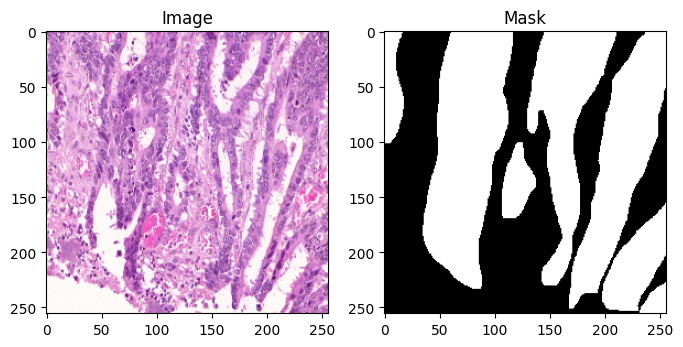

In [25]:
idx = np.random.randint(0, len(X_train))

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(X_train[idx])
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(y_train[idx].squeeze(), cmap="gray")
plt.title("Mask")

plt.show()


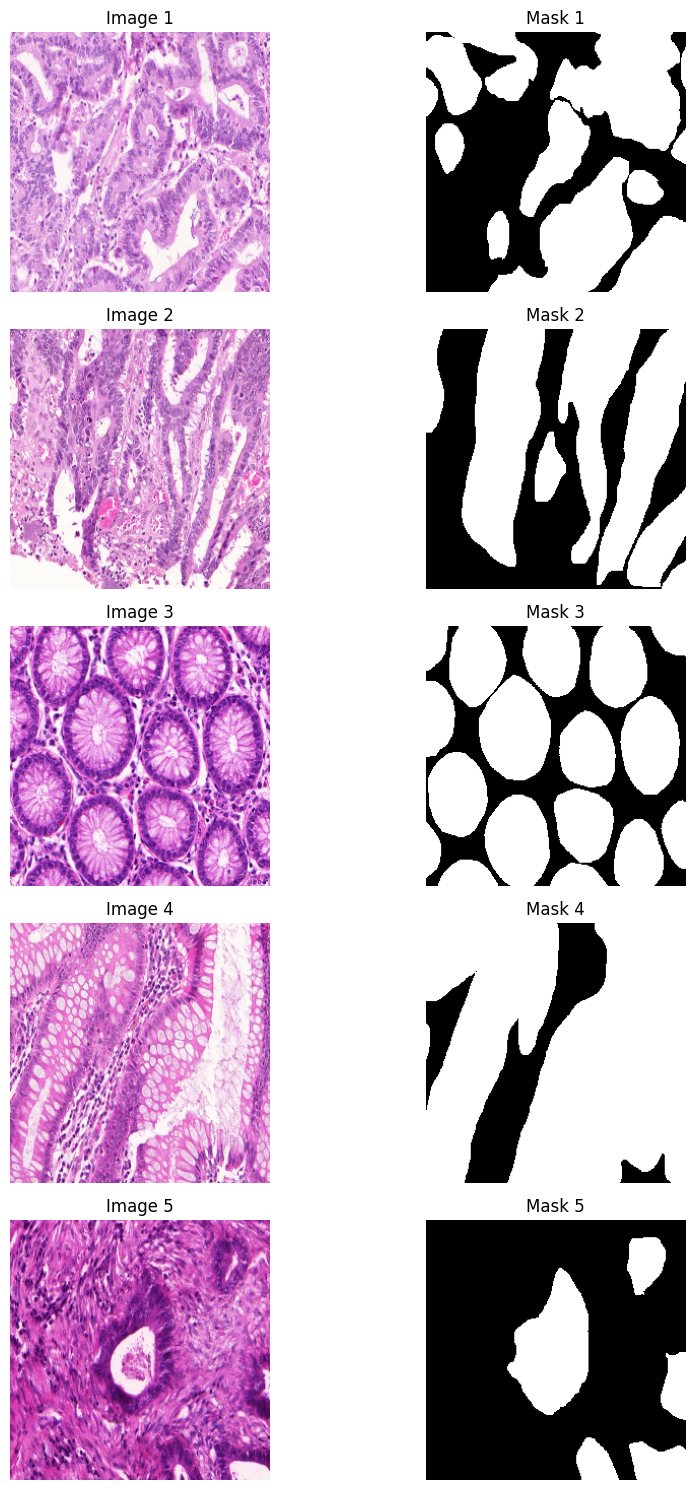

In [26]:
num_images_to_display = 5
fig, axs = plt.subplots(num_images_to_display, 2, figsize=(10, num_images_to_display * 3))

for i in range(num_images_to_display):
    idx = np.random.randint(0, len(X_train))

    # Display Image
    axs[i, 0].imshow(X_train[idx])
    axs[i, 0].set_title(f"Image {i+1}")
    axs[i, 0].axis('off')

    # Display Mask
    axs[i, 1].imshow(y_train[idx].squeeze(), cmap="gray")
    axs[i, 1].set_title(f"Mask {i+1}")
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()

# **U-NET ARCHITECTURE**

In [27]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    return x


def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = layers.Input(input_shape)

    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, 256)

    u1 = layers.UpSampling2D()(c4)
    u1 = layers.Concatenate()([u1, c3])
    c5 = conv_block(u1, 128)

    u2 = layers.UpSampling2D()(c5)
    u2 = layers.Concatenate()([u2, c2])
    c6 = conv_block(u2, 64)

    u3 = layers.UpSampling2D()(c6)
    u3 = layers.Concatenate()([u3, c1])
    c7 = conv_block(u3, 32)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c7)

    return models.Model(inputs, outputs)

# DIce Loss

In [28]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


def dice_loss(y_true, y_pred):
  return 1 - dice_coefficient(y_true, y_pred)

# COMPILE MODEL

In [29]:
model = build_unet()

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coefficient]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]  

 Total params: 1,952,513 (7.45 MB)

 Trainable params: 1,949,697 (7.44 MB)

 Non-trainable params: 2,816 (11.00 KB)

# TRAINING

In [30]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=8,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - dice_coefficient: 0.5332 - loss: 0.4702 - val_dice_coefficient: 0.5094 - val_loss: 0.5002
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - dice_coefficient: 0.6502 - loss: 0.3496 - val_dice_coefficient: 0.5203 - val_loss: 0.4901
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - dice_coefficient: 0.7150 - loss: 0.2846 - val_dice_coefficient: 0.5534 - val_loss: 0.4579
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - dice_coefficient: 0.7445 - loss: 0.2572 - val_dice_coefficient: 0.5735 - val_loss: 0.4386
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - dice_coefficient: 0.7559 - loss: 0.2467 - val_dice_coefficient: 0.5946 - val_loss: 0.4185
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - dice_coefficient: 0.7883 - loss: 0.2145 - val_dice_coefficient: 0.6079 - val_loss: 0.4058
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - dice_coefficient: 0.7896 - loss: 0.2096 - val_dice_coefficient: 0.6267 - val_loss: 0

# EVALUATION

In [31]:
results = model.evaluate(X_test, y_test, verbose=1)
print("Test Loss :", results[0])
print("Test Dice :", results[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - dice_coefficient: 0.8282 - loss: 0.1718
Test Loss : 0.17182320356369019
Test Dice : 0.8281767964363098


# IoU METRIC

In [32]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(np.uint8)
y_test_iou = y_test.astype(np.uint8)

iou = MeanIoU(num_classes=2)
iou.update_state(y_test_iou, y_pred)

print("Mean IoU:", iou.result().numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Mean IoU: 0.75121737


### Explanation of IoU (Intersection over Union) Metric

**IoU**, also known as the Jaccard index, is a crucial metric for evaluating the performance of object detection and semantic segmentation models. It quantifies the similarity between the predicted segmentation mask and the ground truth mask.

**How it's calculated:**

1.  **Intersection:** This is the area where the predicted mask and the ground truth mask overlap. It represents the pixels that were correctly identified as belonging to the object (True Positives).
2.  **Union:** This is the total area covered by both the predicted mask and the ground truth mask. It includes true positives, false positives (pixels predicted as object but are background), and false negatives (pixels that are object but predicted as background).

The formula for IoU is:

$$IoU = \frac{\text{Area of Overlap}}{\text{Area of Union}} = \frac{\text{Intersection}}{\text{Union}}$$

In the context of the `MeanIoU` metric in Keras/TensorFlow, `num_classes=2` indicates a binary segmentation problem (e.g., gland vs. background). The `MeanIoU` calculates the IoU for each class and then averages them. A higher IoU value indicates better segmentation performance, with 1.0 being a perfect match.

In your code:

*   `y_pred = model.predict(X_test)`: Generates raw predictions from the U-Net model.
*   `y_pred = (y_pred > 0.5).astype(np.uint8)`: Thresholds the predictions at 0.5 to convert them into binary masks (0 or 1).
*   `y_test_iou = y_test.astype(np.uint8)`: Ensures the ground truth masks are also in `uint8` format for comparison.
*   `iou = MeanIoU(num_classes=2)`: Initializes the MeanIoU metric for two classes (foreground and background).
*   `iou.update_state(y_test_iou, y_pred)`: Compares the ground truth and predicted masks and updates the internal state of the IoU calculation.
*   `print("Mean IoU:", iou.result().numpy())`: Prints the final Mean IoU score, which represents the average IoU across the two classes.

In [33]:
best_val_dice = max(history.history['val_dice_coefficient'])
print(f"Best Validation Dice Coefficient: {best_val_dice:.4f}")

Best Validation Dice Coefficient: 0.8828


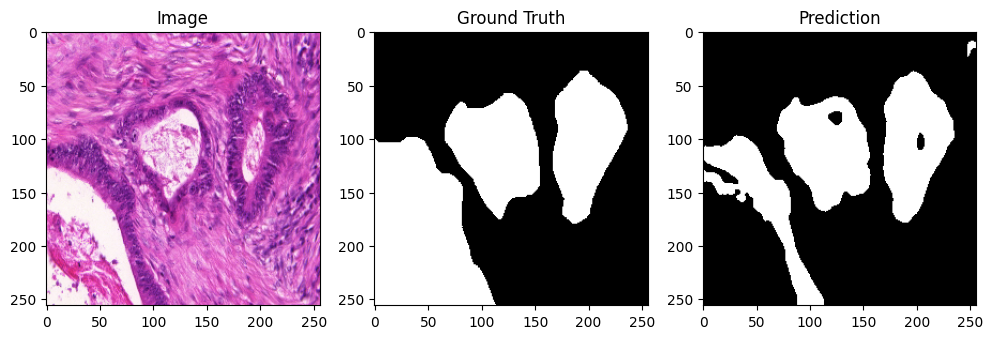

In [34]:
idx = np.random.randint(0, len(X_test))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_test[idx])
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(y_test[idx].squeeze(), cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(y_pred[idx].squeeze(), cmap="gray")
plt.title("Prediction")

plt.show()


# Overlay Visualization (Best for segmentation)

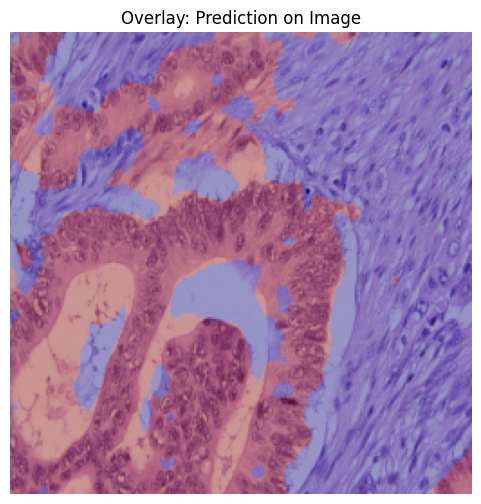

In [35]:
idx = np.random.randint(0, len(X_test))

plt.figure(figsize=(6,6))
plt.imshow(X_test[idx])
plt.imshow(y_pred[idx].squeeze(), cmap='jet', alpha=0.4)
plt.title("Overlay: Prediction on Image")
plt.axis('off')
plt.show()

### Ground Truth Overlay Visualization

Let's visualize the original images with their corresponding ground truth masks overlaid. This helps in understanding the target segmentation visually.

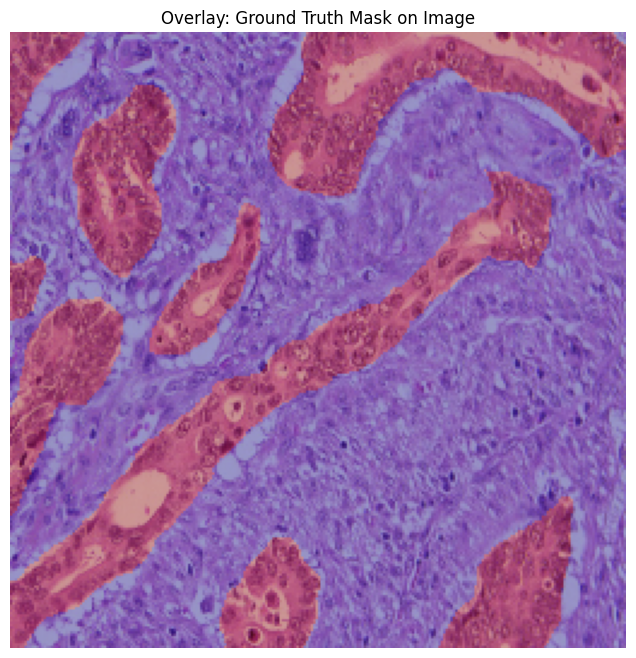

In [36]:
idx = np.random.randint(0, len(X_train))

plt.figure(figsize=(8,8))
plt.imshow(X_train[idx])

# Overlay the ground truth mask with transparency
# Make sure the mask is correctly shaped (2D) for imshow
plt.imshow(y_train[idx].squeeze(), cmap='jet', alpha=0.4)
plt.title("Overlay: Ground Truth Mask on Image")
plt.axis('off')
plt.show()

# Difference Heatmap

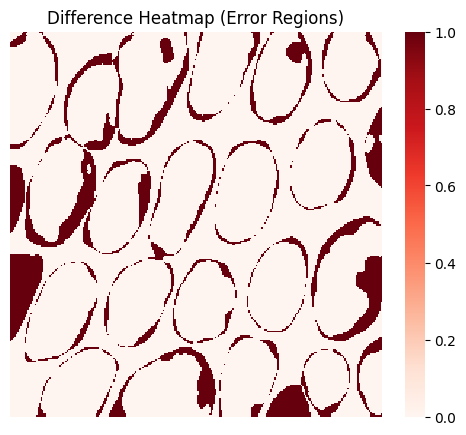

In [37]:
idx = np.random.randint(0, len(X_test))

true_mask = y_test[idx].squeeze()
pred_mask = y_pred[idx].squeeze()

# Absolute difference
diff = np.abs(true_mask - pred_mask)

plt.figure(figsize=(6,5))
sns.heatmap(diff, cmap='Reds', cbar=True)
plt.title("Difference Heatmap (Error Regions)")
plt.axis('off')
plt.show()

# Side-by-Side Visualization

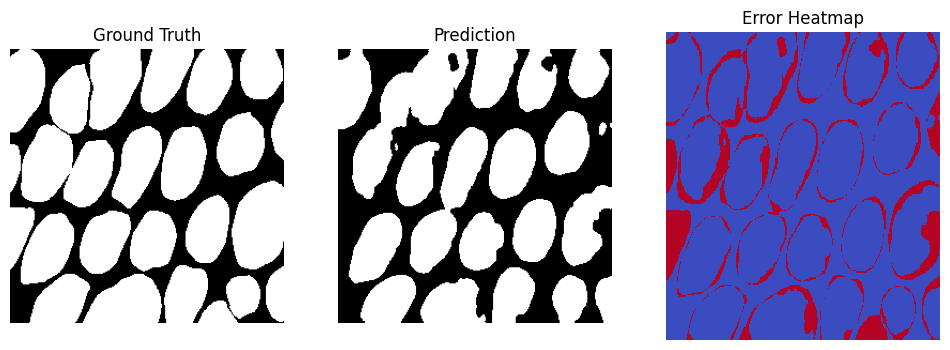

In [38]:
plt.figure(figsize=(12,4))

# Ground Truth
plt.subplot(1,3,1)
plt.imshow(true_mask, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

# Prediction
plt.subplot(1,3,2)
plt.imshow(pred_mask, cmap='gray')
plt.title("Prediction")
plt.axis('off')

# Difference Heatmap
plt.subplot(1,3,3)
sns.heatmap(diff, cmap='coolwarm', cbar=False)
plt.title("Error Heatmap")
plt.axis('off')

plt.show()

# TP / FP / FN Visualization

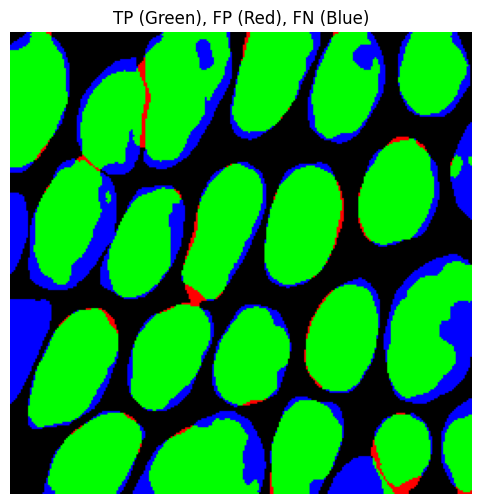

In [39]:
tp = np.logical_and(true_mask == 1, pred_mask == 1)
fp = np.logical_and(true_mask == 0, pred_mask == 1)
fn = np.logical_and(true_mask == 1, pred_mask == 0)

combined = np.zeros((*true_mask.shape, 3))

# True Positive → Green
combined[tp] = [0, 1, 0]

# False Positive → Red
combined[fp] = [1, 0, 0]

# False Negative → Blue
combined[fn] = [0, 0, 1]

plt.figure(figsize=(6,6))
plt.imshow(combined)
plt.title("TP (Green), FP (Red), FN (Blue)")
plt.axis('off')
plt.show()

# Training History Graph

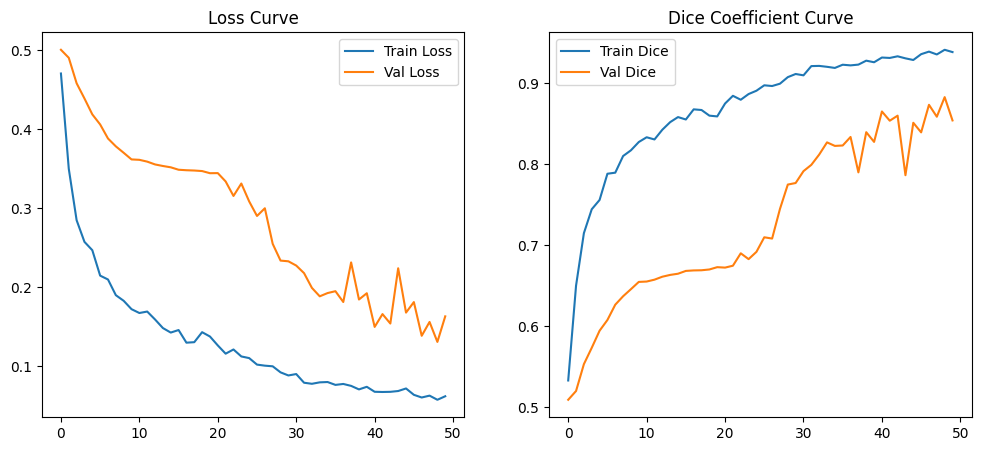

In [40]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()

# Dice Score
plt.subplot(1,2,2)
plt.plot(history.history['dice_coefficient'], label='Train Dice')
plt.plot(history.history['val_dice_coefficient'], label='Val Dice')
plt.title("Dice Coefficient Curve")
plt.legend()

plt.show()